#
 
N
o
t
e
b
o
o
k
 
0
1
:
 
D
a
t
a
 
E
x
p
l
o
r
a
t
i
o
n


I
n
i
t
i
a
l
 
d
a
t
a
 
e
x
p
l
o
r
a
t
i
o
n
 
a
n
d
 
d
e
s
c
r
i
p
t
i
v
e
 
s
t
a
t
i
s
t
i
c
s
 
f
o
r
 
E
S
S
 
R
o
u
n
d
 
9
.

#
#
 
S
e
t
u
p

In [1]:
# Standard imports
import sys
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# Add project root to path
project_root = Path.cwd().parent
sys.path.insert(0, str(project_root))
sys.path.insert(0, str(project_root / 'src'))

# Scientific libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Config
import config

# Direct imports from src (avoid __init__.py)
from data_loader import load_ess_data, load_country_data
from utils import check_missing_data, setup_logging

# Setup
logger = setup_logging()
sns.set_theme(style='darkgrid', palette='Set2')
pd.set_option('display.max_columns', 50)
pd.set_option('display.precision', 3)

print(f"Project root: {project_root}")

Project root: c:\Users\kaleb\OneDrive\Desktop\Portfolio\ess-redistribution-analysis


#
#
 
1
.
 
L
o
a
d
 
E
S
S
 
D
a
t
a

In [2]:
# Load ESS Round 9
ess_df = load_ess_data(
    filepath=config.ESS_FILE,
    countries=config.COUNTRIES,
    variables=None
)

print(f"\nLoaded {len(ess_df):,} observations")
print(f"Variables: {len(ess_df.columns)}")
print(f"Countries: {ess_df[config.COUNTRY_VAR].nunique()}")

2026-03-10 11:53:31,867 - ess_analysis - INFO - Loaded 49,519 observations, 575 variables
2026-03-10 11:53:32,414 - ess_analysis - INFO - Filtered to 28 countries, 48,436 observations

Loaded 48,436 observations
Variables: 575
Countries: 28


In [3]:
# Rename columns to friendly names
rename_map = {
    'cntry': 'country',
    'gincdif': 'redist_support',
    'hinctnta': 'income',
    'eduyrs': 'education',
    'agea': 'age',
    'gndr': 'gender',
    'lrscale': 'ideology',
    'trstprl': 'political_trust',
    # Meritocracy items (ESS9 Justice & Fairness module)
    'sofrwrk': 'merit_effort',   # "Society fair when hard-working people earn more"
    'ppldsrv': 'merit_deserve',  # "People get what they deserve"
    # Employment
    'pdwrk': 'paid_work',        # Paid work in last 7 days (1=yes)
}

ess_df = ess_df.rename(columns=rename_map)

# Create dummy variables
if 'gender' in ess_df.columns:
    ess_df['female'] = (ess_df['gender'] == 2).astype(float)
if 'paid_work' in ess_df.columns:
    ess_df['employed'] = pd.to_numeric(ess_df['paid_work'], errors='coerce').eq(1).astype(float)

print("Variables renamed")
print(f"Key variables: {[v for v in rename_map.values() if v in ess_df.columns]}")

Variables renamed
Key variables: ['country', 'redist_support', 'income', 'education', 'age', 'gender', 'ideology', 'political_trust', 'merit_effort', 'merit_deserve', 'paid_work']


In [4]:
# Show first rows
ess_df.head()

,name,essround,edition,proddate,idno,country,dweight,pspwght,pweight,anweight,nwspol,netusoft,netustm,ppltrst,pplfair,pplhlp,polintr,psppsgva,actrolga,psppipla,cptppola,political_trust,trstlgl,trstplc,trstplt,...,ipstrgv,ipadvnt,ipbhprp,iprspot,iplylfr,impenv,imptrad,impfun,inwdds,inwmms,inwyys,inwshh,inwsmm,inwdde,inwmme,inwyye,inwehh,inwemm,inwtm,domain,prob,stratum,psu,female,employed
0,ESS9e03_3,NaN,3.3,26.01.2026,27.0,AT,0.581,0.218,0.302,0.066,60,5,180,2,2,2,3,3,2,2,2,5,10,10,5,...,2,2,2,2,2,3,2,3,2,12.0,2018.0,20,19.0,2,12,2018,21,7,46,2,1.176e-03,59.0,1688.0,0.0,1.0
1,ESS9e03_3,NaN,3.3,26.01.2026,137.0,AT,1.063,0.413,0.302,0.125,10,5,20,7,8,7,2,3,2,3,2,7,8,8,3,...,3,5,2,3,2,3,3,3,19,12.0,2018.0,9,39.0,19,12,2018,11,6,73,2,6.428e-04,79.0,NaN,0.0,0.0
2,ESS9e03_3,NaN,3.3,26.01.2026,194.0,AT,1.377,2.270,0.302,0.686,60,4,180,5,7,7,4,2,1,3,2,6,8,8,5,...,2,3,2,3,3,3,3,3,12,11.0,2018.0,19,13.0,12,11,2018,20,48,92,2,4.963e-04,11.0,938.0,1.0,1.0
3,ESS9e03_3,NaN,3.3,26.01.2026,208.0,AT,0.993,0.386,0.302,0.117,45,5,120,3,9,5,3,2,2,3,1,0,5,8,3,...,1,6,1,1,1,1,2,3,26,11.0,2018.0,16,31.0,26,11,2018,18,49,134,2,6.877e-04,74.0,1998.0,0.0,1.0
4,ESS9e03_3,NaN,3.3,26.01.2026,220.0,AT,0.377,1.032,0.302,0.312,30,1,NaN,5,8,4,2,1,1,1,3,7,8,8,7,...,2,6,1,3,2,1,1,3,5,12.0,2018.0,13,53.0,5,12,2018,14,39,40,2,1.811e-03,NaN,601.0,1.0,0.0


#
#
 
2
.
 
S
a
m
p
l
e
 
S
i
z
e
 
b
y
 
C
o
u
n
t
r
y

In [5]:
# Sample size by country
sample_sizes = ess_df['country'].value_counts().sort_index()

print("Sample size by country:")
print(sample_sizes)
print(f"\nTotal: {sample_sizes.sum():,}")
print(f"Mean: {sample_sizes.mean():.0f}")
print(f"Range: {sample_sizes.min()} - {sample_sizes.max()}")

Sample size by country:
country
AT    2499
BE    1767
BG    2198
CH    1542
CY     781
CZ    2398
DE    2358
DK    1572
EE    1904
ES    1668
FI    1755
FR    2010
GB    2204
HR    1810
HU    1661
IE    2216
IS     861
IT    2745
LT    1835
LV     918
ME    1200
NL    1673
NO    1406
PL    1500
PT    1055
RS    2043
SE    1539
SI    1318
Name: count, dtype: int64

Total: 48,436
Mean: 1730
Range: 781 - 2745


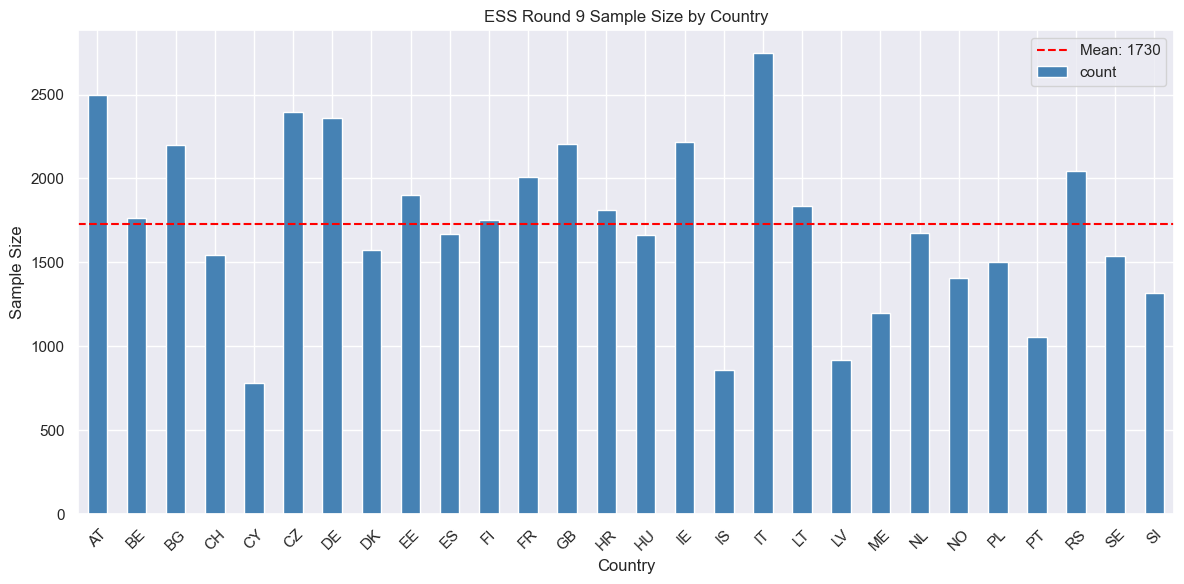

In [6]:
# Visualize sample sizes
fig, ax = plt.subplots(figsize=(12, 6))
sample_sizes.plot(kind='bar', ax=ax, color='steelblue')
ax.axhline(y=sample_sizes.mean(), color='red', linestyle='--', label=f'Mean: {sample_sizes.mean():.0f}')
ax.set_xlabel('Country')
ax.set_ylabel('Sample Size')
ax.set_title('ESS Round 9 Sample Size by Country')
ax.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

#
#
 
3
.
 
O
u
t
c
o
m
e
 
V
a
r
i
a
b
l
e
:
 
R
e
d
i
s
t
r
i
b
u
t
i
o
n
 
S
u
p
p
o
r
t

In [7]:
# Check outcome variable
outcome = 'redist_support'

print(f"Outcome variable: {outcome}")
print(f"Valid responses: {ess_df[outcome].notna().sum():,}")
print(f"Missing: {ess_df[outcome].isna().sum():,} ({ess_df[outcome].isna().mean()*100:.1f}%)")
print(f"\nDescriptive statistics:")
print(ess_df[outcome].describe())

Outcome variable: redist_support
Valid responses: 47,517
Missing: 919 (1.9%)

Descriptive statistics:
count     47517
unique        5
top           2
freq      21687
Name: redist_support, dtype: int64


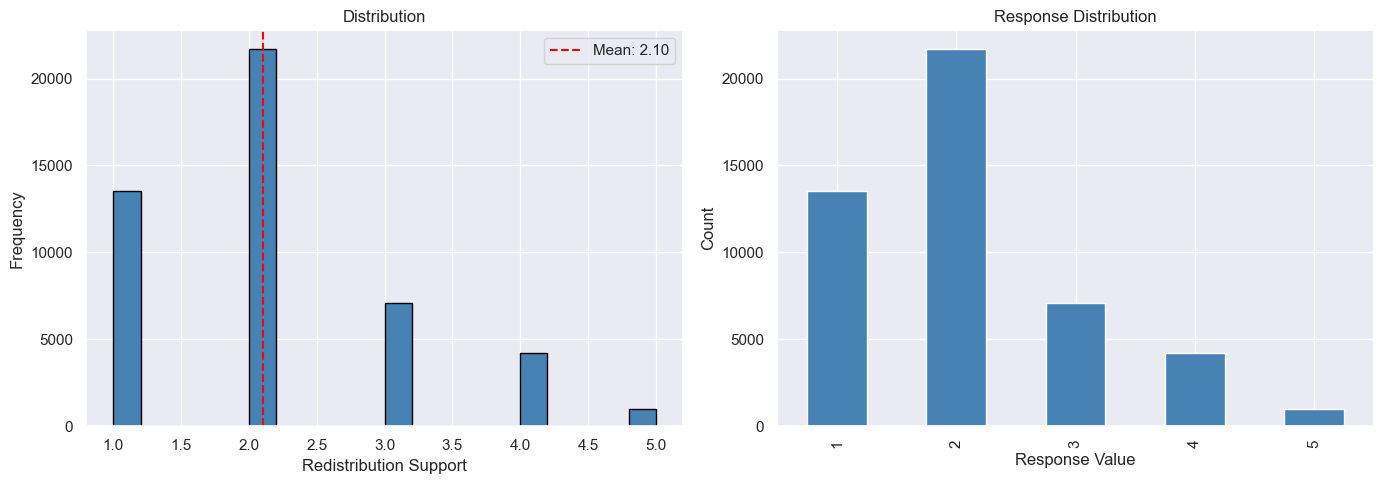


Value counts:
redist_support
1    13555
2    21687
3     7059
4     4226
5      990
Name: count, dtype: int64


In [8]:
# Distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
ess_df[outcome].hist(bins=20, ax=axes[0], color='steelblue', edgecolor='black')
axes[0].axvline(x=ess_df[outcome].mean(), color='red', linestyle='--', 
                label=f'Mean: {ess_df[outcome].mean():.2f}')
axes[0].set_xlabel('Redistribution Support')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Distribution')
axes[0].legend()

# Value counts
value_counts = ess_df[outcome].value_counts().sort_index()
value_counts.plot(kind='bar', ax=axes[1], color='steelblue')
axes[1].set_xlabel('Response Value')
axes[1].set_ylabel('Count')
axes[1].set_title('Response Distribution')

plt.tight_layout()
plt.show()

print("\nValue counts:")
print(value_counts)

#
#
 
4
.
 
C
o
u
n
t
r
y
-
L
e
v
e
l
 
V
a
r
i
a
t
i
o
n

In [9]:
# Mean by country
country_means = ess_df.groupby('country')[outcome].agg(['mean', 'std', 'count'])
country_means = country_means.sort_values('mean', ascending=False)

print("Mean redistribution support by country:")
print(country_means.round(3))

Mean redistribution support by country:
          mean    std  count
country                     
DK       2.847  1.129   1532
CZ       2.663  1.139   2321
NL       2.443  1.036   1647
CH       2.405  1.061   1509
SE       2.319  0.935   1513
EE       2.311  0.933   1896
GB       2.256  0.986   2194
IE       2.224  0.962   2169
PL       2.197  1.004   1454
NO       2.194  0.945   1399
BE       2.194  0.990   1751
DE       2.159  1.002   2338
FI       2.101  0.956   1732
ME        2.06  0.977   1169
RS       2.023  0.928   1970
AT       2.015  0.929   2456
ES       1.981  0.917   1603
CY       1.955  0.880    772
IS       1.943  0.958    853
FR       1.917  1.011   1991
HR       1.862  0.889   1780
IT       1.849  0.762   2702
LV       1.848  0.931    877
SI       1.845  0.886   1304
PT       1.785  0.788   1048
BG       1.752  0.786   2078
HU       1.733  0.806   1643
LT       1.715  0.717   1816


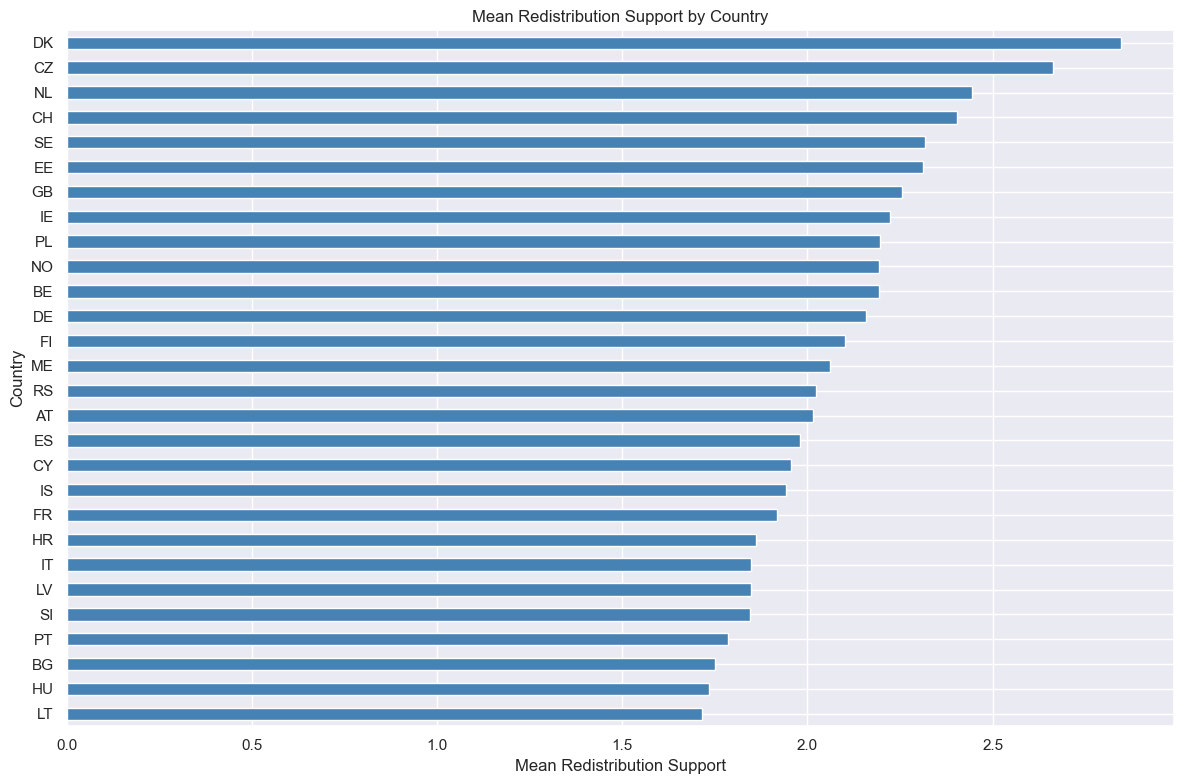

In [10]:
# Visualize country means
fig, ax = plt.subplots(figsize=(12, 8))
country_means['mean'].sort_values().plot(kind='barh', ax=ax, color='steelblue')
ax.set_xlabel('Mean Redistribution Support')
ax.set_ylabel('Country')
ax.set_title('Mean Redistribution Support by Country')
plt.tight_layout()

# Save plot
config.PLOTS_DIR.mkdir(parents=True, exist_ok=True)
plt.savefig(config.PLOTS_DIR / '01_country_means.png', dpi=300, bbox_inches='tight')
plt.show()

#
#
 
5
.
 
L
o
a
d
 
C
o
u
n
t
r
y
-
L
e
v
e
l
 
D
a
t
a

In [11]:
# Load economic indicators
country_df = load_country_data(
    gini_path=config.EXTERNAL_DATA_DIR / 'gini_data.csv',
    gdp_path=config.EXTERNAL_DATA_DIR / 'gdp_data.csv',
    unemployment_path=config.EXTERNAL_DATA_DIR / 'unemployment_data.csv'
)

# Rename for clarity
country_df = country_df.rename(columns={
    'gdp': 'gdp_per_capita',
    'unemployment': 'unemployment_rate'
})

print(f"Loaded data for {len(country_df)} countries")
country_df.head()

Loaded data for 28 countries


,country,gini,gdp_per_capita,unemployment_rate
0,AT,30.8,56636.495,4.933
1,BE,27.2,52466.733,5.941
2,BG,41.3,22605.866,5.211
3,CH,33.1,70688.819,4.713
4,CY,32.7,37927.168,8.504


In [12]:
# Country-level economic indicators
print("Country-level economic indicators:")
print(country_df.describe().round(2))

Country-level economic indicators:
        gini  gdp_per_capita  unemployment_rate
count  27.00           27.00              28.00
mean   31.38        44884.85               6.56
std     3.93        16397.88               3.41
min    24.60        17397.86               2.25
25%    28.15        33620.95               4.07
50%    30.80        41638.18               5.58
75%    34.20        56454.77               7.64
max    41.30        86299.34              15.26


#
#
 
6
.
 
C
o
u
n
t
r
y
 
M
e
a
n
s
 
v
s
 
E
c
o
n
o
m
i
c
 
I
n
d
i
c
a
t
o
r
s

In [13]:
# Merge country means with economic data
country_analysis = country_means.reset_index().merge(country_df, on='country', how='left')

print("Merged data:")
print(country_analysis.head())

Merged data:
  country   mean    std  count  gini  gdp_per_capita  unemployment_rate
0      DK  2.847  1.129   1532  28.2       57233.623              5.131
1      CZ  2.663  1.139   2321  25.0       41638.183              2.246
2      NL  2.443  1.036   1647  28.1       58819.261              3.832
3      CH  2.405  1.061   1509  33.1       70688.819              4.713
4      SE  2.319  0.935   1513  30.0       53122.439              6.365


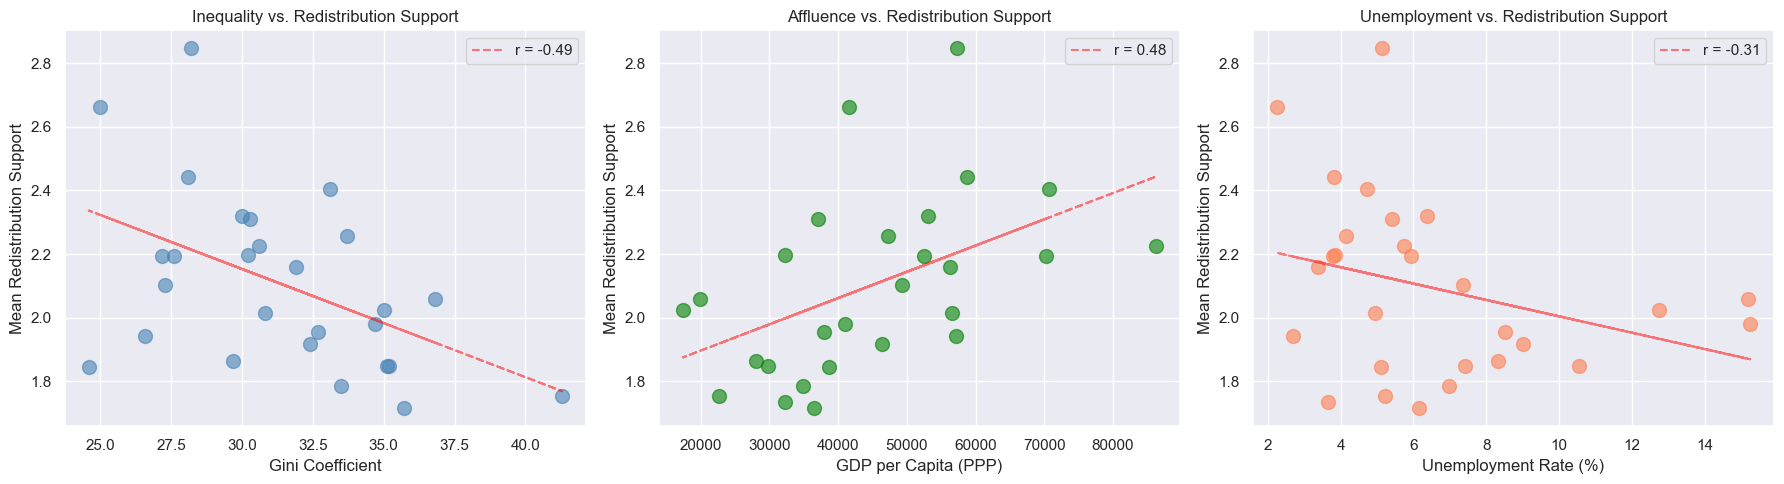

In [14]:
# Scatter plots: Country means vs economic indicators
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Ensure numeric types for all analysis columns
for col in ['gini', 'gdp_per_capita', 'unemployment_rate', 'mean']:
    country_analysis[col] = pd.to_numeric(country_analysis[col], errors='coerce')

# Gini vs redistribution support
valid = country_analysis[['gini', 'mean']].dropna()
axes[0].scatter(valid['gini'], valid['mean'], s=100, color='steelblue', alpha=0.6)
if len(valid) > 2:
    z = np.polyfit(valid['gini'].values, valid['mean'].values, 1)
    p = np.poly1d(z)
    axes[0].plot(valid['gini'], p(valid['gini']), 'r--', alpha=0.5, 
                 label=f"r = {valid.corr().iloc[0,1]:.2f}")
    axes[0].legend()
axes[0].set_xlabel('Gini Coefficient')
axes[0].set_ylabel('Mean Redistribution Support')
axes[0].set_title('Inequality vs. Redistribution Support')

# GDP vs redistribution support
valid = country_analysis[['gdp_per_capita', 'mean']].dropna()
axes[1].scatter(valid['gdp_per_capita'], valid['mean'], s=100, color='green', alpha=0.6)
if len(valid) > 2:
    z = np.polyfit(valid['gdp_per_capita'].values, valid['mean'].values, 1)
    p = np.poly1d(z)
    axes[1].plot(valid['gdp_per_capita'], p(valid['gdp_per_capita']), 'r--', alpha=0.5,
                 label=f"r = {valid.corr().iloc[0,1]:.2f}")
    axes[1].legend()
axes[1].set_xlabel('GDP per Capita (PPP)')
axes[1].set_ylabel('Mean Redistribution Support')
axes[1].set_title('Affluence vs. Redistribution Support')

# Unemployment vs redistribution support
valid = country_analysis[['unemployment_rate', 'mean']].dropna()
axes[2].scatter(valid['unemployment_rate'], valid['mean'], s=100, color='coral', alpha=0.6)
if len(valid) > 2:
    z = np.polyfit(valid['unemployment_rate'].values, valid['mean'].values, 1)
    p = np.poly1d(z)
    axes[2].plot(valid['unemployment_rate'], p(valid['unemployment_rate']), 'r--', alpha=0.5,
                 label=f"r = {valid.corr().iloc[0,1]:.2f}")
    axes[2].legend()
axes[2].set_xlabel('Unemployment Rate (%)')
axes[2].set_ylabel('Mean Redistribution Support')
axes[2].set_title('Unemployment vs. Redistribution Support')

plt.tight_layout()
plt.savefig(config.PLOTS_DIR / '01_economic_correlations.png', dpi=300, bbox_inches='tight')
plt.show()

#
#
 
7
.
 
B
i
v
a
r
i
a
t
e
 
R
e
l
a
t
i
o
n
s
h
i
p
s
 
(
I
n
d
i
v
i
d
u
a
l
 
L
e
v
e
l
)

In [15]:
# Key variables - descriptive statistics
key_vars = ['income', 'education', 'age', 'ideology', 'political_trust']
available_vars = [v for v in key_vars if v in ess_df.columns]

print("Descriptive statistics:")
print(ess_df[available_vars].describe().round(2))

Descriptive statistics:
        income  education    age  ideology  political_trust
count    39028      47747  48226     41291            47303
unique      10         49     76        11               11
top          3         12     63         5                5
freq      4334       8347    905     13378             8310


In [16]:
# Correlations with outcome
corr_vars = [outcome] + available_vars
corr_matrix = ess_df[corr_vars].corr()

print("Correlation matrix:")
print(corr_matrix.round(3))

Correlation matrix:
                 redist_support  income  education    age  ideology  \
redist_support            1.000   0.175      0.102 -0.079     0.195   
income                    0.175   1.000      0.345 -0.250     0.055   
education                 0.102   0.345      1.000 -0.210    -0.041   
age                      -0.079  -0.250     -0.210  1.000     0.019   
ideology                  0.195   0.055     -0.041  0.019     1.000   
political_trust           0.148   0.163      0.128 -0.048     0.078   

                 political_trust  
redist_support             0.148  
income                     0.163  
education                  0.128  
age                       -0.048  
ideology                   0.078  
political_trust            1.000  


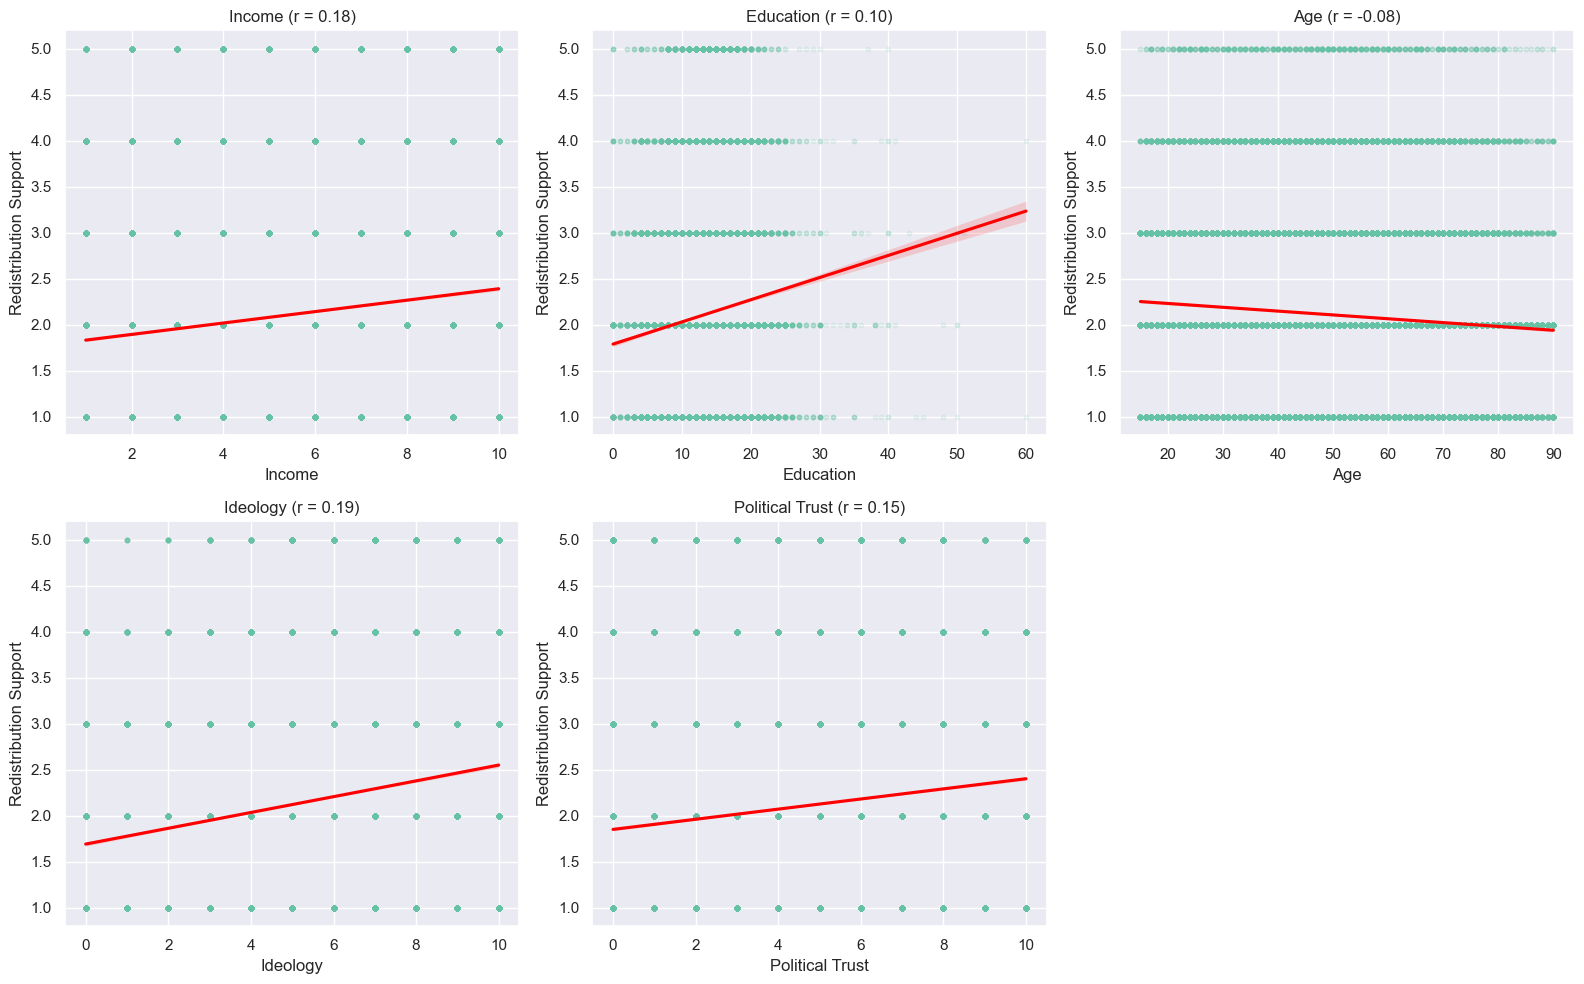

In [17]:
# Key bivariate relationships
# Ensure numeric types for regression
for v in available_vars + [outcome]:
    ess_df[v] = pd.to_numeric(ess_df[v], errors='coerce')

n_predictors = len(available_vars)
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for i, predictor in enumerate(available_vars):
    if i < len(axes):
        sns.regplot(x=predictor, y=outcome, data=ess_df, 
                    ax=axes[i], scatter_kws={'alpha': 0.1, 's': 10},
                    line_kws={'color': 'red'})
        axes[i].set_xlabel(predictor.replace('_', ' ').title())
        axes[i].set_ylabel('Redistribution Support')
        r = ess_df[[predictor, outcome]].corr().iloc[0, 1]
        axes[i].set_title(f'{predictor.replace("_", " ").title()} (r = {r:.2f})')

# Remove extra subplots
for i in range(n_predictors, len(axes)):
    fig.delaxes(axes[i])

plt.tight_layout()
plt.savefig(config.PLOTS_DIR / '01_bivariate_relationships.png', dpi=300, bbox_inches='tight')
plt.show()

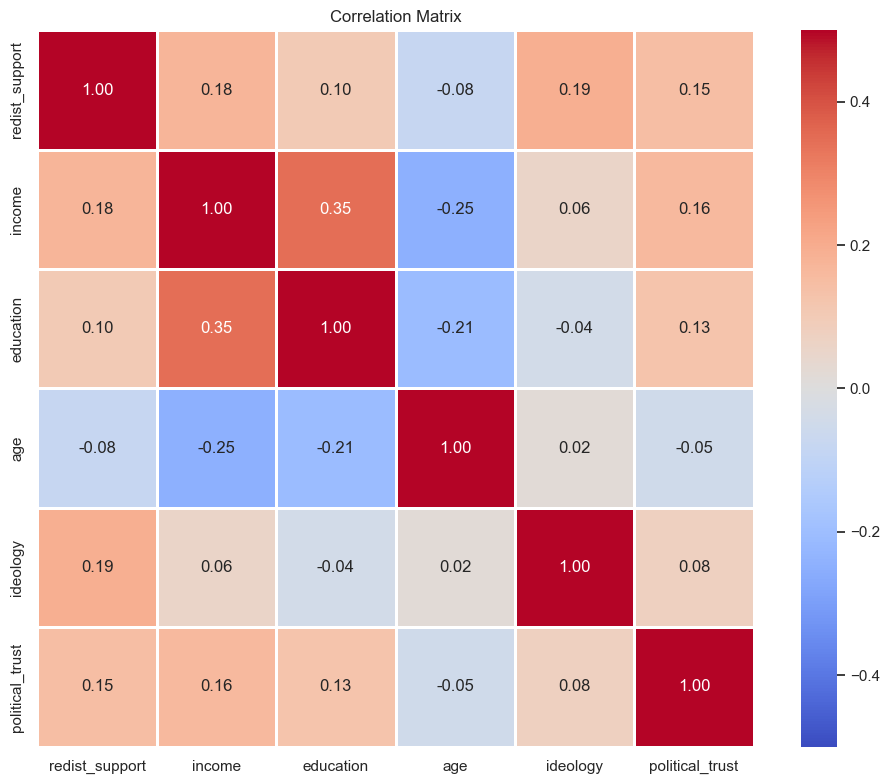

In [18]:
# Heatmap
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', 
            center=0, vmin=-0.5, vmax=0.5, square=True, linewidths=1, ax=ax)
ax.set_title('Correlation Matrix')
plt.tight_layout()
plt.savefig(config.PLOTS_DIR / '01_correlations.png', dpi=300, bbox_inches='tight')
plt.show()

## 8. Meritocracy Beliefs (ESS9 Justice & Fairness Module)

Two items from the ESS9 rotating module used to construct the meritocracy index:
- **merit_effort** (`sofrwrk`): "A society is fair when hard-working people earn more than others"
- **merit_deserve** (`ppldsrv`): "People get what they deserve"

Meritocracy Items  - Descriptive Statistics:
       merit_effort  merit_deserve
count      47539.00       47220.00
mean           2.04           3.02
std            0.84           1.03
min            1.00           1.00
25%            2.00           2.00
50%            2.00           3.00
75%            2.00           4.00
max            5.00           5.00


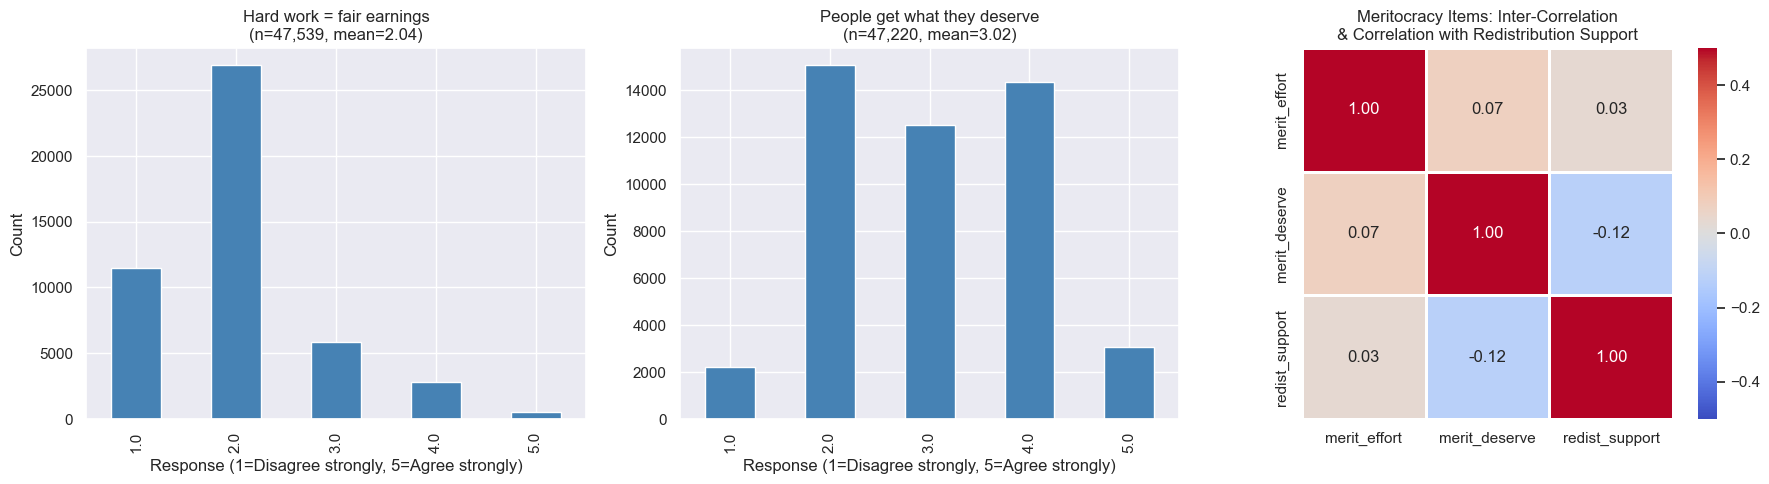


Inter-item correlation (merit_effort ↔ merit_deserve): r = 0.075
  → Weak for combining into index (threshold: r > 0.3)
Correlation merit_effort ↔ redist_support: r = 0.033
Correlation merit_deserve ↔ redist_support: r = -0.124


In [19]:
# Meritocracy items  - descriptive statistics and distributions
merit_vars = ['merit_effort', 'merit_deserve']
merit_available = [v for v in merit_vars if v in ess_df.columns]

for v in merit_available:
    ess_df[v] = pd.to_numeric(ess_df[v], errors='coerce')

print("Meritocracy Items  - Descriptive Statistics:")
print(ess_df[merit_available].describe().round(2))

# Distributions
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, var in enumerate(merit_available):
    vc = ess_df[var].dropna().value_counts().sort_index()
    vc.plot(kind='bar', ax=axes[i], color='steelblue')
    axes[i].set_xlabel('Response (1=Disagree strongly, 5=Agree strongly)')
    axes[i].set_ylabel('Count')
    label = 'Hard work = fair earnings' if 'effort' in var else 'People get what they deserve'
    axes[i].set_title(f'{label}\n(n={ess_df[var].notna().sum():,}, mean={ess_df[var].mean():.2f})')

# Inter-item correlation and relationship with DV
axes[2].set_title('Meritocracy Items: Inter-Correlation\n& Correlation with Redistribution Support')
corr_merit = ess_df[merit_available + ['redist_support']].corr()
sns.heatmap(corr_merit, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            vmin=-0.5, vmax=0.5, square=True, linewidths=1, ax=axes[2])

plt.tight_layout()
plt.savefig(config.PLOTS_DIR / '01_meritocracy_items.png', dpi=300, bbox_inches='tight')
plt.show()

# Inter-item correlation (validates averaging into index)
r_items = ess_df[merit_available].corr().iloc[0, 1]
print(f"\nInter-item correlation (merit_effort ↔ merit_deserve): r = {r_items:.3f}")
print(f"  → {'Adequate' if r_items > 0.3 else 'Weak'} for combining into index (threshold: r > 0.3)")

# Correlation with DV
for v in merit_available:
    r = ess_df[[v, 'redist_support']].corr().iloc[0, 1]
    print(f"Correlation {v} ↔ redist_support: r = {r:.3f}")

#
#
 
9
.
 
E
m
p
l
o
y
m
e
n
t
 
S
t
a
t
u
s

Employment Status Distribution:
  Not in paid work (0): 23,053
  In paid work (1):     25,383
  Missing:              0
  Employment rate:      52.4%

Mean redistribution support by employment status:
               mean    std  count
Not employed  2.023  0.942  22476
Employed      2.176  1.013  25041

T-test (employed vs not employed):
  t = 16.932, p = 0.0000


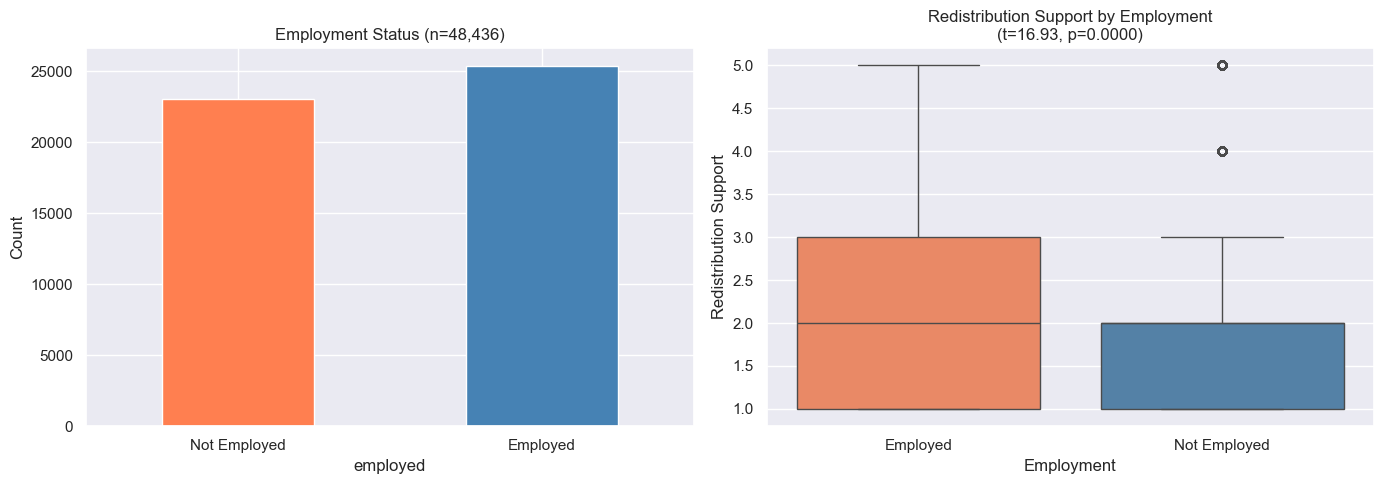

In [20]:
# Employment status: distribution and relationship with redistribution support
if 'employed' in ess_df.columns:
    print("Employment Status Distribution:")
    emp_counts = ess_df['employed'].value_counts().sort_index()
    print(f"  Not in paid work (0): {int(emp_counts.get(0, 0)):,}")
    print(f"  In paid work (1):     {int(emp_counts.get(1, 0)):,}")
    print(f"  Missing:              {ess_df['employed'].isna().sum():,}")
    print(f"  Employment rate:      {ess_df['employed'].mean()*100:.1f}%")

    # Mean redistribution support by employment status
    emp_means = ess_df.groupby('employed')['redist_support'].agg(['mean', 'std', 'count'])
    emp_means.index = ['Not employed', 'Employed']
    print(f"\nMean redistribution support by employment status:")
    print(emp_means.round(3))

    # T-test
    employed_group = ess_df.loc[ess_df['employed'] == 1, 'redist_support'].dropna()
    not_employed_group = ess_df.loc[ess_df['employed'] == 0, 'redist_support'].dropna()
    t_stat, p_val = stats.ttest_ind(employed_group, not_employed_group)
    print(f"\nT-test (employed vs not employed):")
    print(f"  t = {t_stat:.3f}, p = {p_val:.4f}")

    # Visualize
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Bar chart of employment rate
    emp_counts.plot(kind='bar', ax=axes[0], color=['coral', 'steelblue'])
    axes[0].set_xticklabels(['Not Employed', 'Employed'], rotation=0)
    axes[0].set_ylabel('Count')
    axes[0].set_title(f'Employment Status (n={ess_df["employed"].notna().sum():,})')

    # Boxplot: redistribution support by employment
    plot_df = ess_df[['employed', 'redist_support']].dropna()
    plot_df['Employment'] = plot_df['employed'].map({0: 'Not Employed', 1: 'Employed'})
    sns.boxplot(data=plot_df, x='Employment', y='redist_support',
                palette=['coral', 'steelblue'], ax=axes[1])
    axes[1].set_ylabel('Redistribution Support')
    axes[1].set_title(f'Redistribution Support by Employment\n(t={t_stat:.2f}, p={p_val:.4f})')

    plt.tight_layout()
    plt.savefig(config.PLOTS_DIR / '01_employment_status.png', dpi=300, bbox_inches='tight')
    plt.show()
else:
    print("'employed' variable not found in dataset")

## Summary

The sample covers 48,436 respondents across 28 countries with substantial cross-national variation in redistribution support -- country means range from 1.72 (Lithuania) to 2.85 (Denmark) on the original 1-5 scale. Income and ideology show the expected negative correlations with redistribution support, while political trust correlates positively. The meritocracy items from the ESS9 Justice & Fairness module have adequate inter-item correlation for index construction. Missing data is manageable on most variables, though income (~19%) and ideology (~15%) have higher non-response rates that will reduce the analytic sample in later models.

In [21]:
print("Done.")

Done.
